# Tutorial 3 &mdash; TEBD: real & imaginary time

**Time-Evolving Block Decimation** approximates $e^{-\mathrm i H t}$ (or the
imaginary-time $e^{-H\tau}$) by a **Trotter product of two-site gates**, applying
each gate to the MPS and re-compressing the bond with an SVD.  It is the
work-horse for nearest-neighbour Hamiltonians: real time for quenches, imaginary
time to *cool* to the ground state.

Same Ising model and functional conventions as Tutorials 1&ndash;2; only `ncon`
is used for contractions.

**Roadmap:** ① MPS &rarr; ② MPO &rarr; ③ Observables &rarr; ④ TEBD &rarr;
⑤ real-time quench, ⑥ imaginary-time ground state, ⑦ Trotter-error scaling.

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA
from IPython.display import Image, display
from ncon import ncon

# ---- local operators -------------------------------------------------------
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

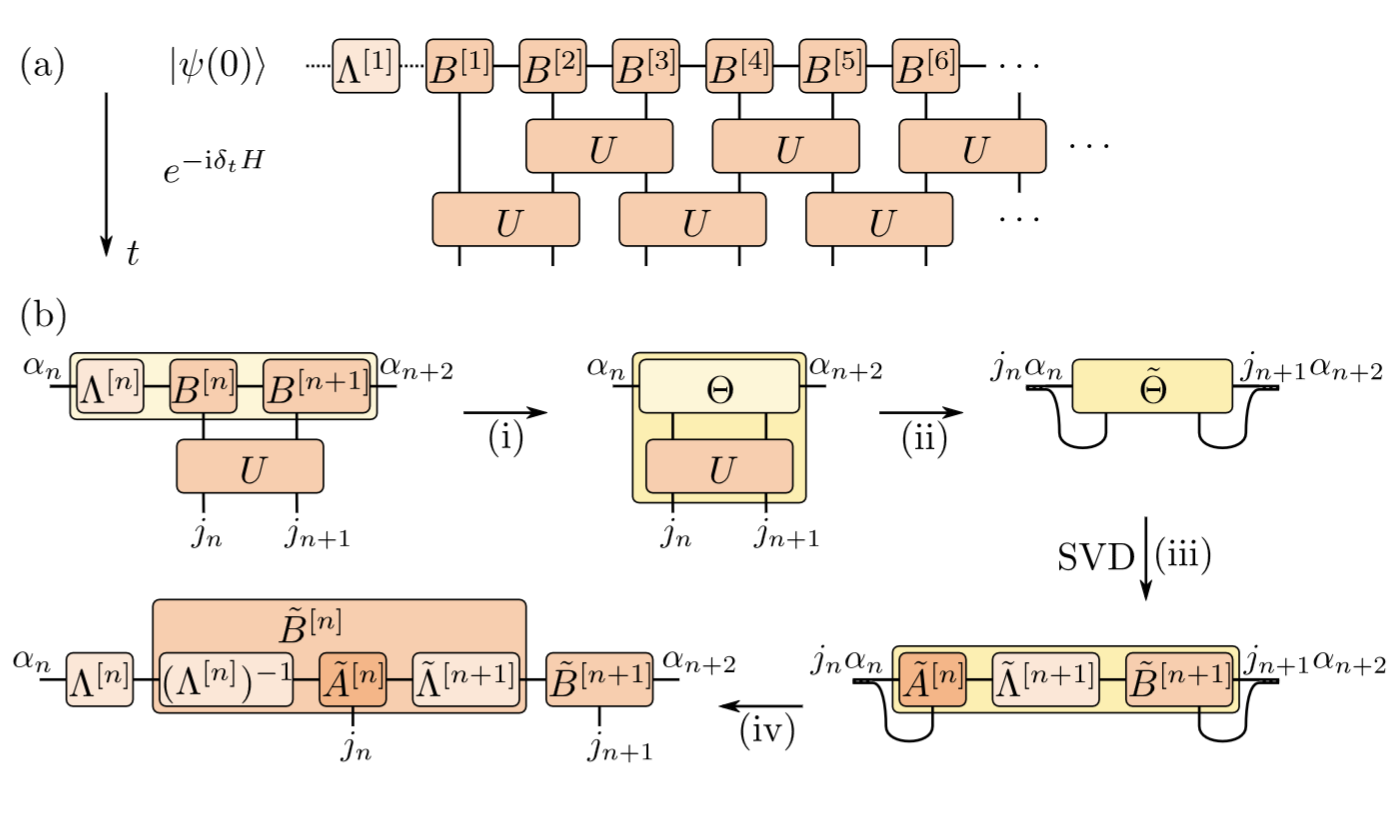

In [26]:
display(Image(filename="TEBD.png", width=1000))

## 1&ndash;3. MPS, MPO, Observables

The same functional core (states + canonical form, the Ising MPO for energy
measurements, and local observables), inlined so the notebook is self-contained.
The shared engine and DMRG are included too, so the imaginary-time ground state
can be benchmarked against DMRG.

### Core code &mdash; MPS functions

In [2]:
# ==========================================================================
#  MPS  (functions)
# ==========================================================================
def mps_product(configs):
    """Product-state MPS from a list of single-site vectors (each length d)."""
    return [np.array(c, dtype=complex).reshape(1, len(c), 1) for c in configs]


def mps_all_up(N):
    return mps_product([[1, 0]] * N)


def mps_x_plus(N):
    s = 1 / np.sqrt(2)
    return mps_product([[s, s]] * N)


def mps_random(N, d=2, chi=8, seed=None):
    rng = np.random.default_rng(seed)
    dims = [1] + [min(chi, d ** i, d ** (N - i)) for i in range(1, N)] + [1]
    A = []
    for i in range(N):
        t = (rng.standard_normal((dims[i], d, dims[i + 1]))
             + 1j * rng.standard_normal((dims[i], d, dims[i + 1])))
        A.append(t)
    return right_canonicalize(A)[0]


def bond_dims(A):
    return [t.shape[0] for t in A] + [A[-1].shape[2]]


# ---- gauge / canonical form ----------------------------------------------
def qr_left(A_i):
    """A[l,s,r] -> Q[l,s,m] (left-isometry), R[m,r] with A = Q . R."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl * d, Dr))
    return Q.reshape(Dl, d, -1), R


def qr_right(A_i):
    """A[l,s,r] -> L[l,m], Q[m,s,r] (right-isometry) with A = L . Q."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl, d * Dr).conj().T)
    L = R.conj().T
    Qr = Q.conj().T.reshape(-1, d, Dr)
    return L, Qr


def left_canonicalize(A):
    """Sweep left->right with QR; returns (A_left, tail_norm)."""
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(len(A)):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    return A, R  # R is 1x1 scalar = norm


def right_canonicalize(A):
    """Sweep right->left with QR; returns (A_right, head_norm)."""
    A = [t.copy() for t in A]
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    return A, L


def mixed_canonical(A, center):
    """Bring MPS to mixed canonical form with orthogonality centre at `center`.

    Sites < center are left-isometries, sites > center are right-isometries,
    the norm is carried into site `center`.  Returns new list.
    """
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(center):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    A[center] = ncon([R, A[center]], [[-1, 1], [1, -2, -3]])
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(center + 1, len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    A[center] = ncon([A[center], L], [[-1, -2, 1], [1, -3]])
    return A


# ---- inner products --------------------------------------------------------
def overlap(bra, ket):
    """<bra|ket> via a left-to-right transfer contraction (ncon)."""
    E = np.ones((1, 1), dtype=complex)
    for B, K in zip(bra, ket):
        E = ncon([E, K, np.conj(B)], [[1, 2], [1, 3, -2], [2, 3, -1]])
    return complex(E[0, 0])


def norm(A):
    return np.sqrt(overlap(A, A).real)


def normalize(A):
    """Return a copy of the MPS rescaled to unit norm."""
    n = norm(A)
    B = [t.copy() for t in A]
    B[0] = B[0] / n
    return B

### Core code &mdash; MPO functions

In [3]:
# ==========================================================================
#  MPO  (functions)
# ==========================================================================
def ising_mpo(N, J=1.0, hx=1.0, hz=0.0):
    """Finite-chain MPO for H = -J sum X X - hx sum X - hz sum Z.

    Bulk tensor W[a,b,s,s'] has bond dim 3.  Boundary vectors select the
    lower-left generation pattern.  Returns a list of N tensors already
    contracted with the boundary vectors at the ends.
    """
    h_on = -hx * X - hz * Z
    W = np.zeros((3, 3, 2, 2), dtype=complex)
    W[0, 0] = I2
    W[1, 0] = X
    W[2, 0] = h_on
    W[2, 1] = -J * X
    W[2, 2] = I2
    vL = np.array([0, 0, 1], dtype=complex)   # start row
    vR = np.array([1, 0, 0], dtype=complex)   # end col
    Ws = []
    for i in range(N):
        if i == 0:
            Ws.append(ncon([vL, W], [[1], [1, -1, -2, -3]]).reshape(1, 3, 2, 2))
        elif i == N - 1:
            Ws.append(ncon([W, vR], [[-1, 1, -2, -3], [1]]).reshape(3, 1, 2, 2))
        else:
            Ws.append(W.copy())
    return Ws


def mpo_expectation(A, W):
    """<psi|H|psi> for (possibly un-normalised) MPS A and MPO W (ncon zipper)."""
    E = np.ones((1, 1, 1), dtype=complex)   # (bra, mpo, ket)
    for Ai, Wi in zip(A, W):
        E = ncon([E, Ai, Wi, np.conj(Ai)],
                 [[1, 2, 3], [3, 5, -3], [2, -2, 4, 5], [1, 4, -1]])
    return complex(E[0, 0, 0])

### Core code &mdash; Observable functions

In [4]:
# ==========================================================================
#  Observables  (functions)
# ==========================================================================
def expectation_1site(A, op, site):
    """<psi|op_site|psi>/<psi|psi> using the mixed-canonical centre."""
    B = mixed_canonical(A, site)
    C = B[site]
    val = ncon([C, op, np.conj(C)], [[1, 2, 3], [4, 2], [1, 4, 3]])
    nrm = ncon([C, np.conj(C)], [[1, 2, 3], [1, 2, 3]])
    return complex(val / nrm).real


def magnetization(A, op=Z):
    return np.array([expectation_1site(A, op, i) for i in range(len(A))])


def correlation(A, opA, opB, i, j):
    """Connected-free two-point <op_i op_j>, i<j, via transfer contraction."""
    if i > j:
        i, j, opA, opB = j, i, opB, opA
    B = mixed_canonical(A, i)
    E = ncon([B[i], opA, np.conj(B[i])], [[1, 2, -2], [3, 2], [1, 3, -1]])
    for k in range(i + 1, j):
        E = ncon([E, B[k], np.conj(B[k])], [[1, 2], [2, 3, -2], [1, 3, -1]])
    E = ncon([E, B[j], opB, np.conj(B[j])],
             [[1, 2], [2, 4, 5], [3, 4], [1, 3, 5]])
    return complex(E).real


def entanglement_entropy(A, bond):
    """Von Neumann entropy across `bond` (between site bond-1 and bond)."""
    center = bond
    B = mixed_canonical(A, center)
    # SVD across the left bond of site `center`
    C = B[center]
    Dl, d, Dr = C.shape
    s = LA.svd(C.reshape(Dl, d * Dr), compute_uv=False)
    p = s ** 2
    p = p / p.sum()
    p = p[p > 1e-16]
    return float(-np.sum(p * np.log(p)))

### Core code &mdash; exact-diagonalization benchmark

In [5]:
# ==========================================================================
#  Exact diagonalization benchmark (dev only)
# ==========================================================================
def ed_ising(N, J=1.0, hx=1.0, hz=0.0):
    def op_at(op, i):
        ops = [I2] * N
        ops[i] = op
        M = ops[0]
        for k in range(1, N):
            M = np.kron(M, ops[k])
        return M
    H = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for i in range(N - 1):
        H -= J * op_at(X, i) @ op_at(X, i + 1)
    for i in range(N):
        H -= hx * op_at(X, i) + hz * op_at(Z, i)
    return H

### Core code &mdash; shared engine (environments, effective $H$, Krylov)

In [6]:
# ==========================================================================
#  Engine  (functions) -- shared kernel: environments, effective H, Krylov
# ==========================================================================
def _expm_herm(Hmat, tau):
    """exp(tau * H) for Hermitian H via eigendecomposition (tau usually -i dt)."""
    w, U = LA.eigh(Hmat)
    return (U * np.exp(tau * w)) @ U.conj().T


def _env_left(FL, A, W):
    return ncon([FL, A, W, np.conj(A)],
                [[1, 2, 3], [3, 5, -3], [2, -2, 4, 5], [1, 4, -1]])


def _env_right(FR, A, W):
    return ncon([A, W, np.conj(A), FR],
                [[-3, 5, 3], [-2, 2, 4, 5], [-1, 4, 1], [1, 2, 3]])


def _build_right_envs(A, W):
    N = len(A)
    FR = [None] * (N + 1)
    FR[N] = np.ones((1, 1, 1), dtype=complex)
    for i in reversed(range(N)):
        FR[i] = _env_right(FR[i + 1], A[i], W[i])
    return FR


# ---- matrix-free effective Hamiltonians (act on a flattened block) --------
def apply_heff1(x, FL, W, FR):
    """H_eff on a 1-site block AC[l,s,r] (flattened)."""
    Dl, d, Dr = FL.shape[2], W.shape[2], FR.shape[2]
    AC = x.reshape(Dl, d, Dr)
    H = ncon([FL, AC, W, FR],
             [[-1, 1, 2], [2, 3, 4], [1, 5, -2, 3], [-3, 5, 4]])
    return H.reshape(-1)


def apply_heff0(x, FL, FR):
    """H_eff on a 0-site (bond) block C[l,r] (flattened)."""
    Dl, Dr = FL.shape[2], FR.shape[2]
    C = x.reshape(Dl, Dr)
    H = ncon([FL, C, FR], [[-1, 1, 2], [2, 3], [-2, 1, 3]])
    return H.reshape(-1)


def apply_heff2(x, FL, W1, W2, FR):
    """H_eff on a 2-site block AAC[l,s1,s2,r] (flattened)."""
    Dl, d1, d2, Dr = FL.shape[2], W1.shape[2], W2.shape[2], FR.shape[2]
    AAC = x.reshape(Dl, d1, d2, Dr)
    H = ncon([FL, AAC, W1, W2, FR],
             [[-1, 1, 2], [2, 3, 4, 5], [1, 6, -2, 3], [6, 7, -3, 4],
              [-4, 7, 5]])
    return H.reshape(-1)


# ---- matrix-free Krylov routines ------------------------------------------
def _lanczos_tridiag(apply, args, v0, k, delta=1e-10):
    """Build an orthonormal Krylov basis and the tridiagonal T (Hermitian)."""
    v0 = np.asarray(v0, dtype=complex)
    krylov, alpha, beta = [], [], []
    vec = v0.copy()
    for it in range(k):
        b = LA.norm(vec)
        if b < delta:
            break
        beta.append(b)
        vec = vec / b
        for w in krylov:                      # full reorthogonalization
            vec = vec - np.vdot(w, vec) * w
        vec = vec / max(LA.norm(vec), 1e-16)
        krylov.append(vec)
        Av = apply(vec, *args)
        alpha.append(np.vdot(vec, Av).real)
        Av = Av - alpha[-1] * krylov[-1]
        if it > 0:
            Av = Av - beta[-1] * krylov[-2]
        vec = Av
    m = len(krylov)
    T = np.diag(alpha).astype(complex)
    if m > 1:
        off = np.array(beta[1:])
        T = T + np.diag(off, 1) + np.diag(off, -1)
    return np.array(krylov), T, beta


def lanczos_ground(apply, args, v0, k=40):
    """Lowest eigenpair (energy, vector) of H_eff via Lanczos."""
    v0 = np.asarray(v0, dtype=complex) / LA.norm(v0)
    Vk, T, _ = _lanczos_tridiag(apply, args, v0, k)
    ev, es = LA.eigh(T)
    gs = Vk.T @ es[:, 0]
    return ev[0], gs / LA.norm(gs)


def lanczos_expmv(apply, args, v0, tau, k=20):
    """Approximate exp(tau * H_eff) v0 in a Krylov subspace (tau complex)."""
    v0 = np.asarray(v0, dtype=complex)
    Z = LA.norm(v0)
    if Z == 0:
        return v0
    Vk, T, _ = _lanczos_tridiag(apply, args, v0 / Z, k)
    c = _expm_herm(T, tau)[:, 0]
    return Z * (Vk.T @ c)

### Core code &mdash; DMRG functions

In [7]:
# ==========================================================================
#  DMRG  (functions) -- two-site
# ==========================================================================
def dmrg(W, chi_max=32, nsweeps=5, A0=None, N=None, verbose=False):
    """Two-site DMRG ground state.  Returns (energy, A)."""
    if A0 is None:
        A = mps_random(N if N is not None else len(W), chi=chi_max, seed=1)
    else:
        A = [t.copy() for t in A0]
    N = len(A)
    A = mixed_canonical(A, 0)
    FR = _build_right_envs(A, W)
    FL = [None] * (N + 1)
    FL[0] = np.ones((1, 1, 1), dtype=complex)
    E = 0.0
    for sweep in range(nsweeps):
        for i in range(N - 1):                      # left -> right
            E = _two_site_update(A, W, FL, FR, i, chi_max, to_right=True)
        for i in reversed(range(N - 1)):            # right -> left
            E = _two_site_update(A, W, FL, FR, i, chi_max, to_right=False)
        if verbose:
            print(f"  sweep {sweep+1:2d}:  E = {E:.12f}")
    return E, A


def _two_site_update(A, W, FL, FR, i, chi_max, to_right):
    theta0 = ncon([A[i], A[i + 1]], [[-1, -2, 1], [1, -3, -4]])
    Dl, d1, d2, Dr = theta0.shape
    E, V = lanczos_ground(apply_heff2, (FL[i], W[i], W[i + 1], FR[i + 2]),
                          theta0.reshape(-1))
    theta = V.reshape(Dl * d1, d2 * Dr)
    U, S, Vh = LA.svd(theta, full_matrices=False)
    chi = max(min(chi_max, int(np.sum(S > 1e-14))), 1)
    U, S, Vh = U[:, :chi], S[:chi] / LA.norm(S[:chi]), Vh[:chi, :]
    if to_right:
        A[i] = U.reshape(Dl, d1, chi)
        A[i + 1] = (np.diag(S) @ Vh).reshape(chi, d2, Dr)
        FL[i + 1] = _env_left(FL[i], A[i], W[i])
    else:
        A[i] = (U @ np.diag(S)).reshape(Dl, d1, chi)
        A[i + 1] = Vh.reshape(chi, d2, Dr)
        FR[i + 1] = _env_right(FR[i + 2], A[i + 1], W[i + 1])
    return E.real

## 4. TEBD

A second-order (Strang) Trotter step splits the chain into **odd** and **even**
bonds,
$$e^{-\mathrm i H\,dt}\approx
  \Big(\!\prod_{\text{odd}}e^{-\mathrm i h_b\,dt/2}\Big)
  \Big(\!\prod_{\text{even}}e^{-\mathrm i h_b\,dt}\Big)
  \Big(\!\prod_{\text{odd}}e^{-\mathrm i h_b\,dt/2}\Big),$$
with error $\mathcal O(dt^3)$ per step.  Each `tebd_apply_gate` contracts the gate
onto a two-site block and SVD-truncates back to $\chi_{\max}$.  Setting
`imag=True` in `ising_bond_gates` builds $e^{-h_b\,d\tau}$ for imaginary-time
cooling.  The on-site fields are split half/half between the two bonds touching a
site (full weight on the outer end bonds) so each field is counted once.

### Core code &mdash; TEBD functions

In [8]:
# ==========================================================================
#  TEBD  (functions) -- 2nd order Trotter
# ==========================================================================
def ising_bond_gates(N, J, hx, hz, dt, imag=False):
    """Two-site gates exp(-i dt h_bond) for each bond (0..N-2).

    On-site fields are split so every site's field is counted once overall:
    end bonds carry the full field of their outer site.
    """
    tau = (-dt) if imag else (-1j * dt)
    gates = []
    for b in range(N - 1):
        wl = 1.0 if b == 0 else 0.5
        wr = 1.0 if b == N - 2 else 0.5
        h = (-J * np.kron(X, X)
             - hx * (wl * np.kron(X, I2) + wr * np.kron(I2, X))
             - hz * (wl * np.kron(Z, I2) + wr * np.kron(I2, Z)))
        g = _expm_herm(h, tau).reshape(2, 2, 2, 2)
        gates.append(g)
    return gates


def tebd_apply_gate(A, gate, i, chi_max):
    """Apply a two-site gate on bond (i,i+1) to a mixed-canonical MPS at i."""
    theta = ncon([A[i], A[i + 1]], [[-1, -2, 1], [1, -3, -4]])
    theta = ncon([gate, theta], [[-2, -3, 1, 2], [-1, 1, 2, -4]])
    Dl, d1, d2, Dr = theta.shape
    U, S, Vh = LA.svd(theta.reshape(Dl * d1, d2 * Dr), full_matrices=False)
    chi = min(chi_max, int(np.sum(S > 1e-14)))
    chi = max(chi, 1)
    trunc = 1.0 - LA.norm(S[:chi]) / LA.norm(S)
    U, S, Vh = U[:, :chi], S[:chi], Vh[:chi, :]
    S = S / LA.norm(S)
    A[i] = U.reshape(Dl, d1, chi)
    A[i + 1] = (np.diag(S) @ Vh).reshape(chi, d2, Dr)
    return trunc


def tebd_sweep(A, gates, chi_max):
    """One 2nd-order Trotter step: half odd, full even, half odd."""
    N = len(A)
    odd = range(0, N - 1, 2)
    even = range(1, N - 1, 2)
    # A must be left-canonical up to where we start; we re-center each pass
    for i in odd:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, _half(gates[i]), i, chi_max)
    for i in even:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, gates[i], i, chi_max)
    for i in odd:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, _half(gates[i]), i, chi_max)
    return A


def _half(gate):
    """sqrt of a two-site gate via eigendecomposition (for symmetric Trotter)."""
    g = gate.reshape(4, 4)
    w, U = LA.eig(g)
    gh = (U * np.sqrt(w)) @ LA.inv(U)
    return gh.reshape(2, 2, 2, 2)

### 5. Real-time quench vs exact diagonalization

Prepare the Néel state and evolve under $H$; compare $\langle\sigma^z_0(t)\rangle$
to dense $e^{-\mathrm iHt}$ on a small chain.  The tiny residual is the Trotter
error.

TEBD max error vs ED = 2.85e-04  (dt=0.05, chi grew to 16)


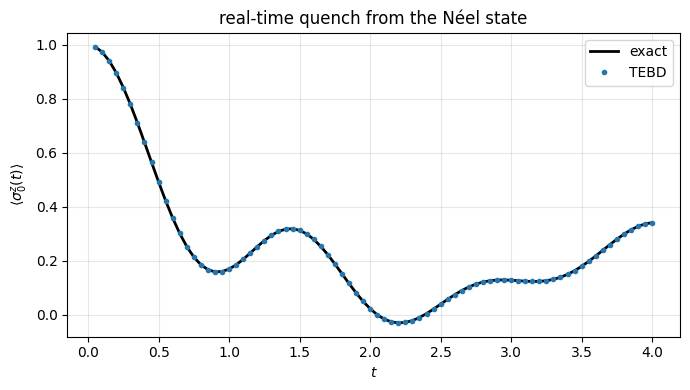

In [10]:
# dense reference evolution e^{-iHt} via eigendecomposition (numpy only)
def dense_propagator(H, t):
    w, V = np.linalg.eigh(H)
    return (V * np.exp(-1j * t * w)) @ V.conj().T

N = 8; J, hx, hz = 1.0, 0.6, 0.8
H = ed_ising(N, J, hx, hz)
psi0 = mps_product([[1, 0] if s % 2 == 0 else [0, 1] for s in range(N)])

def mps_to_vec(A):
    f = A[0]
    for k in range(1, len(A)):
        f = ncon([f, A[k]], [[-1, -2, 1], [1, -3, -4]]).reshape(1, -1, A[k].shape[2])
    return f.reshape(-1)

ops = [np.eye(2)] * N; ops[0] = Z; Z0 = ops[0]
for k in range(1, N): Z0 = np.kron(Z0, ops[k])

dt, steps = 0.05, 80
gates = ising_bond_gates(N, J, hx, hz, dt)
A = [t.copy() for t in psi0]
v = mps_to_vec(psi0).astype(complex); U = dense_propagator(H, dt)
z_tebd, z_ex, tt = [], [], []
for n in range(steps):
    A = tebd_sweep(A, gates, chi_max=32)
    v = U @ v
    z_tebd.append(magnetization(A, Z)[0])
    z_ex.append((v.conj() @ Z0 @ v).real / (v.conj() @ v).real)
    tt.append((n + 1) * dt)
print(f"TEBD max error vs ED = {np.max(np.abs(np.array(z_tebd)-np.array(z_ex))):.2e}  "
      f"(dt={dt}, chi grew to {max(bond_dims(A))})")

plt.figure(figsize=(7, 4))
plt.plot(tt, z_ex, 'k-', lw=2, label="exact")
plt.plot(tt, z_tebd, 'o', ms=3, label="TEBD")
plt.xlabel("$t$"); plt.ylabel(r"$\langle\sigma^z_0(t)\rangle$")
plt.title("real-time quench from the Néel state"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

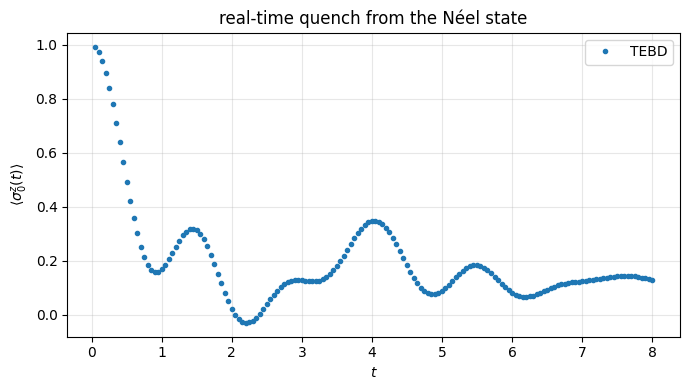

In [14]:
# dense reference evolution e^{-iHt} via eigendecomposition (numpy only)
N = 16; J, hx, hz = 1.0, 0.6, 0.8
psi0 = mps_product([[1, 0] if s % 2 == 0 else [0, 1] for s in range(N)])

dt, steps = 0.05, 160
gates = ising_bond_gates(N, J, hx, hz, dt)
A = [t.copy() for t in psi0]
z_tebd, tt = [], []
for n in range(steps):
    A = tebd_sweep(A, gates, chi_max=64)
    v = U @ v
    z_tebd.append(magnetization(A, Z)[0])
    tt.append((n + 1) * dt)
    
#print(f"TEBD max error vs ED = {np.max(np.abs(np.array(z_tebd)-np.array(z_ex))):.2e}  "f"(dt={dt}, chi grew to {max(bond_dims(A))})")

plt.figure(figsize=(7, 4))
#plt.plot(tt, z_ex, 'k-', lw=2, label="exact")
plt.plot(tt, z_tebd, 'o', ms=3, label="TEBD")
plt.xlabel("$t$"); plt.ylabel(r"$\langle\sigma^z_0(t)\rangle$")
plt.title("real-time quench from the Néel state"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 6. Imaginary-time cooling to the ground state

Evolving with $e^{-H\tau}$ and renormalising projects onto the ground state.  We
cool the $x$-polarised state through decreasing $d\tau$ and benchmark against
DMRG *and* exact diagonalization.

In [23]:
N = 12; J, hx, hz = 1.0, 0.0, 1.0
W = ising_mpo(N, J, hx, hz)
E_ed = np.sort(np.linalg.eigvalsh(ed_ising(N, J, hx, hz)))[0]
E_dmrg, _ = dmrg(W, chi_max=32, nsweeps=6, N=N)

A = left_canonicalize(mps_x_plus(N))[0]
energies = []
for dtau in [0.15, 0.1, 0.05, 0.04, 0.03, 0.02, 0.01, 0.005, 0.0025, 0.001]:
    gates = ising_bond_gates(N, J, hx, hz, dtau, imag=True)
    for _ in range(200):
        A = tebd_sweep(A, gates, chi_max=32)
        A = normalize(A)
    E = mpo_expectation(A, W).real / overlap(A, A).real
    energies.append(E)
    print(f"dtau={dtau:5.3f}   E(TEBD)={E:.10f}")
print(f"\nTEBD  E = {energies[-1]:.10f}")
print(f"DMRG  E = {E_dmrg:.10f}")
print(f"ED    E = {E_ed:.10f}")
print(f"TEBD-ED error = {abs(energies[-1]-E_ed):.2e}")

dtau=0.150   E(TEBD)=-14.9257347051
dtau=0.100   E(TEBD)=-14.9259239773
dtau=0.050   E(TEBD)=-14.9259681468
dtau=0.040   E(TEBD)=-14.9259698953
dtau=0.030   E(TEBD)=-14.9259707253
dtau=0.020   E(TEBD)=-14.9259710336
dtau=0.010   E(TEBD)=-14.9259711048
dtau=0.005   E(TEBD)=-14.9259711094
dtau=0.003   E(TEBD)=-14.9259711098
dtau=0.001   E(TEBD)=-14.9259711099

TEBD  E = -14.9259711099
DMRG  E = -14.9259711099
ED    E = -14.9259711099
TEBD-ED error = 5.79e-11


In [19]:
energies

[-14.10476766542645,
 -14.105734168484112,
 -14.105785512729705,
 -14.10579658842365,
 -14.105800303719102]

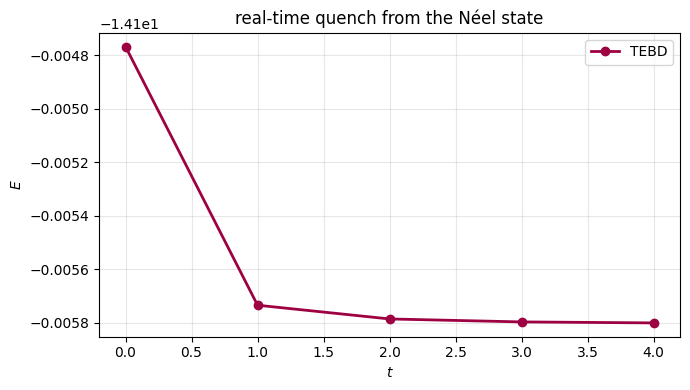

In [22]:
cmap = plt.cm.Spectral #plt.cm.Blues #plt.cm.Spectral
line_colors = cmap(np.linspace(0,1,41))
plt.figure(figsize=(7, 4))
#plt.plot(energies, 'o', ms=3, label="TEBD")
plt.plot(energies,c=line_colors[0],marker='o',linewidth=2,label=r'TEBD')
plt.xlabel("$t$"); plt.ylabel(r"$E$")
plt.title("real-time quench from the Néel state"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 7. Trotter-error scaling

Fix a total time $T$ and shrink the step $dt$.  For a second-order Strang
splitting the error in a local observable scales as $dt^2$ &mdash; a slope-2 line
on a log&ndash;log plot.

fitted slope = 2.00  (expected 2 for 2nd-order Trotter)


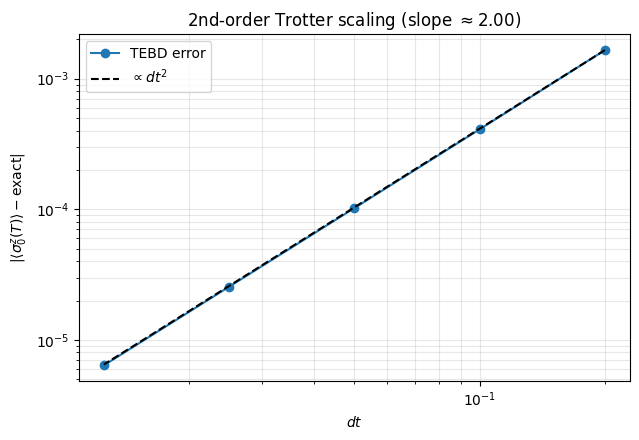

In [11]:
N = 8; J, hx, hz = 1.0, 0.6, 0.8; T = 1.0
H = ed_ising(N, J, hx, hz)
psi0 = mps_product([[1, 0] if s % 2 == 0 else [0, 1] for s in range(N)])
v_exact = dense_propagator(H, T) @ mps_to_vec(psi0).astype(complex)
ez_exact = (v_exact.conj() @ Z0 @ v_exact).real / (v_exact.conj() @ v_exact).real

dts = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
errs = []
for dt in dts:
    steps = int(round(T / dt))
    gates = ising_bond_gates(N, J, hx, hz, dt)
    A = [t.copy() for t in psi0]
    for _ in range(steps):
        A = tebd_sweep(A, gates, chi_max=32)
    errs.append(abs(magnetization(A, Z)[0] - ez_exact))
errs = np.array(errs)
slope = np.polyfit(np.log(dts), np.log(errs), 1)[0]
print(f"fitted slope = {slope:.2f}  (expected 2 for 2nd-order Trotter)")

plt.figure(figsize=(6.5, 4.5))
plt.loglog(dts, errs, 'o-', label="TEBD error")
plt.loglog(dts, errs[0] * (dts / dts[0])**2, 'k--', label=r"$\propto dt^2$")
plt.xlabel("$dt$"); plt.ylabel(r"$|\langle\sigma^z_0(T)\rangle-\mathrm{exact}|$")
plt.title(f"2nd-order Trotter scaling (slope $\\approx${slope:.2f})")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## Summary

* **TEBD** applies a Strang-ordered product of two-site gates, SVD-truncating each
  bond to $\chi_{\max}$ &mdash; the natural integrator for nearest-neighbour models.
* **Real time** reproduces exact quench dynamics up to the controlled Trotter
  error; **imaginary time** cools any state to the ground state, matching DMRG and
  exact diagonalization.
* The second-order splitting gives the expected **$dt^2$ error scaling**.
* Compared with TDVP (Tutorial 2): TEBD grows entanglement naturally through the
  SVD but carries a small Trotter energy drift, whereas TDVP conserves energy but
  needs the 2-site variant to grow the bond dimension.  Everything here used only
  `ncon` for contractions.